# ASSIGNMENT 3: Decision trees and random forests


## Business understanding (Riikka)


As internet has become widely available for everyone and setting up a website is easier than ever, the number of insecure and unreliable websites that are trying to collect personal information from the visitors has also become more prevalent. The main goal of this analysis is to determine whether a machine learning model can correctly predict these phishing websites based on different website-related features. The objectives are to create two different models using the Decision Tree and Random Forest algorithms and to validate, analyse and compare the performance results of the models. One of the models should achieve a score of at least 85% in accuracy, precision and recall for the goal to be reached.


## Data understanding


Pandas and MatplotLib libraries are imported to handle the dataset and create visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

The assignment uses the Phishing dataset that is available at the UCI Machine learning Repository (https://archive.ics.uci.edu/ml/datasets/phishing+websites). The dataset is fetched from the source and divided into `X` and `y`. `X` contains features that describe characteristics of a website, while `y` contains the target indicating whether the website is phishing or legitimate.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 
  
# data (as pandas dataframes) 
X = phishing_websites.data.features 
y = phishing_websites.data.targets
y = y['result']
  
# variable information 
phishing_websites.variables

,name,role,type,demographic,description,units,missing_values
0,having_ip_address,Feature,Integer,None,None,None,no
1,url_length,Feature,Integer,None,None,None,no
2,shortining_service,Feature,Integer,None,None,None,no
3,having_at_symbol,Feature,Integer,None,None,None,no
4,double_slash_redirecting,Feature,Integer,None,None,None,no
5,prefix_suffix,Feature,Integer,None,None,None,no
6,having_sub_domain,Feature,Integer,None,None,None,no
7,sslfinal_state,Feature,Integer,None,None,None,no
8,domain_registration_length,Feature,Integer,None,None,None,no
9,favicon,Feature,Integer,None,None,None,no


The variable metadata shows that the dataset contains 30 feature variables. All variables are stored as `Integer` values, and there are no missing values.

The feature data use the values `-1`, `0`, `1`. The dataset's documentation itself does not clearly specify how feature values should be interpreted. However, Khan et al. explicitly describe this same dataset and state that -1 represents phishing, 0 represents suspicious and 1 represents legitimate for the feature values. We adopt this convention.

In [3]:
X

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11050,1,-1,1,-1,1,1,1,1,-1,-1,...,-1,-1,-1,1,1,-1,-1,1,1,1
11051,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,1,-1,1,1,1,1,1,1,-1,1
11052,1,-1,1,1,1,-1,1,-1,-1,1,...,1,1,1,1,1,1,-1,1,0,1
11053,-1,-1,1,1,1,-1,-1,-1,1,-1,...,1,-1,1,1,1,1,-1,1,1,1


The `X` dataframe contains 11055 observations and 30 features. Each row represents one website, and the columns describe different characteristics of the website.

In [4]:
y


0       -1
1       -1
2       -1
3       -1
4        1
        ..
11050    1
11051   -1
11052   -1
11053   -1
11054   -1
Name: result, Length: 11055, dtype: int64

The target variable contains 11055 labels. In this analysis, the two target values are `-1 = phishing website` and `1 = legitimate website`.

In [5]:
y.unique()

array([-1,  1])

The output confirms that the target contains only two unique values `-1` and `1`. Therefore, the problem is treated as a binary classification problem.

## Data preparation


The provided data is already suitable for modeling, so no additional data preparation is required. There are no missing values, and all features are already numeric integers, so one-hot encoding is not necessary. Standardization is also not needed because decision trees and random forests split observations according to feature values and do not require values to be on the same scale. Therefore, the original feature values can be used directly without changing the dataframe.

## Modeling


The split validation method is used for testing the model's performance. The original dataframe is divided into training (75%) and testing (25%) data using `train_test_split` function from the `Scikit-learn library`. The random seed is set to 20 to make the split reproducible. The split was done once before either decision tree or the random forest was built. Therefore, both models are evaluated on exactly the same held-out test set, which makes their performance results directly comparable.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20) # extract test set
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8291, 30) (2764, 30) (8291,) (2764,)


This means that 8291 websites (75%) are used for training and 2764 (25%) are reserved for testing. Both sets contain 30 features. The test set is not used to train the models, so it provides an evaluation of how the models perform on data they have not seen during training.

### Part 1: Decision tree (Sandra)

The split data was tested with various hyperparameters to determine which ones would produce the best results.

Values tested for `max_depth`: 6, 4, 3, and 2. Across the tested range, a deeper tree gave better and more accurate results, but at the cost of readability. Since the goal is to keep the tree readable by a human, a max depth of 3 was chosen as a compromise between readability and not being too restrictive. A max depth of 2 gave almost identical scores, but it was not chosen because its `feature_importances_` contained only 2 non-zero columns, which was deemed too few to say anything useful about the data.

`ccp_alpha` was also tested with values 0.014, 0.012 and 0.006. All three produced results identical to the tree at max depth of 2, but they offered no advantage over limiting the depth directly so `max_depth` was kept.

This table contains the test results for each parameter, with the chosen configuration highlighted. Phishing is considered as the positive class, so a false positive is a legitimate site flagged as phishing. Accordingly, a false negative is a phishing site that got flagged as legitimate.

| max_depth | ccp_alpha | precision (phishing) | precision (legitimate) | false positive | false negative | depth |
| --------- | --------- | -------------------- | ---------------------- | -------------- | -------------- | ----- |
| 6         | -         | 0.92                 | 0.94                   | 92             | 87             | 6     |
| 4         | -         | 0.90                 | 0.93                   | 118            | 110            | 4     |
| **3**     | -         | **0.88**             | **0.93**               | **145**        | **109**        | **3** |
| 2         | -         | 0.88                 | 0.93                   | 148            | 109            | 2     |
| -         | 0.014     | 0.88                 | 0.93                   | 148            | 109            | 2     |
| -         | 0.012     | 0.88                 | 0.93                   | 148            | 109            | 2     |
| -         | 0.006     | 0.88                 | 0.93                   | 148            | 109            | 3     |


In [7]:
model = DecisionTreeClassifier(max_depth=3, random_state=20)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Plotting the figure with matplotlib confirms the tree has a max depth of 3.


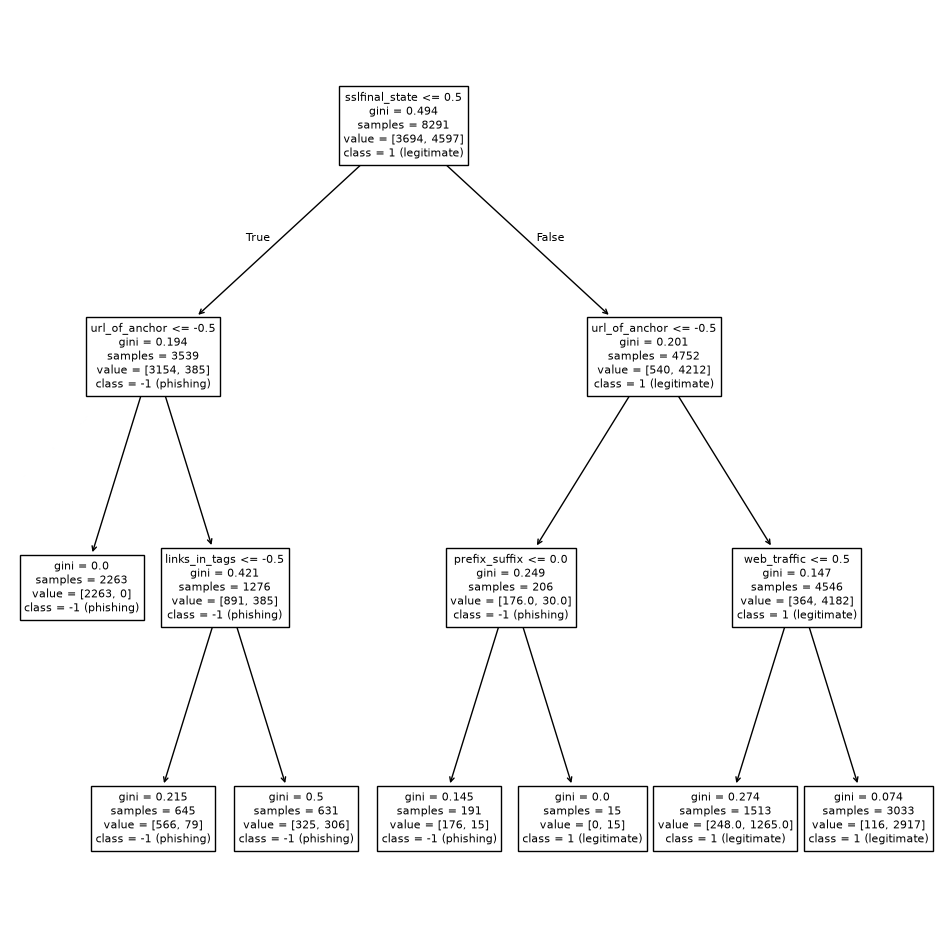

In [8]:
fig = plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = X.keys(), class_names = ['-1 (phishing)', '1 (legitimate)'])
plt.show()

For each node, the condition is written on the first line, e.g. the root node condition is `sslfinal_state <= 0.5`. If the condition is true, the left child is followed, and if false, the right child is followed. `gini` measures how mixed the samples in a node are. A gini of 0.5 means the two classes are evenly divided and the node doesn't lean to either side, while a gini of 0 means every sample in the node belongs to one class, in which case no more child nodes are generated no matter the tree depth. `samples` indicates how many rows reached the node and `value` shows how those rows are distributed between the two result classes. `class` is the prediction the node itself would make, did it not have any child nodes, which is whichever class has more samples in `value`.

Results from `classification_report` and `confusion_matrix` are used to determine which hyperparameters to use for the DecisionTreeClassifier model. The precision column is examined to determine which parameters performed best. For the confusion matrix, the fewer false positives and false negatives there are, the better.


In [9]:
from sklearn.metrics import classification_report

preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          -1       0.88      0.91      0.90      1204
           1       0.93      0.91      0.92      1560

    accuracy                           0.91      2764
   macro avg       0.91      0.91      0.91      2764
weighted avg       0.91      0.91      0.91      2764



In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_test, preds)

array([[1095,  109],
       [ 145, 1415]])

Feature importances show which columns had the most effect on the decision tree's predictions. From most to least important:

- `sslfinal_state` - 82.4%
- `url_of_anchor` - 12.9%
- `links_in_tags` - 2.8%
- `web_traffic` - 1.1%
- `prefix_suffix` - 0.8%

Every other column has an importance of exactly 0, because a tree limited to 3 levels and does not have the room nor need to include the other 25. Allowing the tree to grow deeper brings in more columns, but each additional column would have a diminishing amount of importance, so drawing a line at some point is essential for human readability.


In [11]:
print(model.feature_importances_)

[0.         0.         0.         0.         0.         0.00793356
 0.         0.82392507 0.         0.         0.         0.
 0.         0.12927903 0.0281527  0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.01070965 0.         0.         0.         0.        ]


#### Instructions for manually reviewing websites

Below are instructions for reviewing websites manually to determine whether they are likely to be legitimate or phishing websites. The steps below follow the decision tree graph, only written in human understandable language.

Steps to follow:

1.0. Does the website use a trusted SSL certificate?<br>
Yes -> Proceed to 2.2<br>
No -> Proceed to 2.1

2.1. Does the anchor link point to a different website?<br>
Yes -> **Phishing website**<br>
No -> Proceed to 3.1

2.2. Does the anchor link point to a different website?<br>
Yes -> Proceed to 3.2<br>
No -> Proceed to 3.3

3.1. Do the links in tags point to different websites?<br>
Yes -> **Phishing website**<br>
No -> **Phishing website**

3.2. Does the website address contain a prefix or suffix?<br>
Yes -> **Phishing website**<br>
No -> **Legitimate website**

3.3. Does the website have traffic?<br>
Yes -> **Legitimate website**<br>
No -> **Legitimate website**


### Part 2: Random forest (Anni)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

# Create a random forest classifier (Testausta: max_samples: 0.7 ja max_features: 0.75 | max_samples: 0.8 ja max_features: 0.75 | max_samples: 0.8 ja max_features: 0.65 | max_samples: 0.8 ja max_features: 0.55)
model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples=0.8, max_features=0.65, random_state=123)
model.fit(X_train, y_train)

print(model.feature_importances_)

[0.00961339 0.00723887 0.00318827 0.00399919 0.00183765 0.02740422
 0.03630334 0.48849419 0.01306909 0.00315135 0.00169354 0.00415361
 0.01210491 0.21565745 0.03363347 0.01113436 0.00530521 0.00246226
 0.00412184 0.00222387 0.00119104 0.00302288 0.0015666  0.01362943
 0.00918091 0.04133199 0.00939208 0.01159841 0.0184594  0.00383716]


In [13]:
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          -1       0.97      0.97      0.97      1204
           1       0.97      0.98      0.98      1560

    accuracy                           0.97      2764
   macro avg       0.97      0.97      0.97      2764
weighted avg       0.97      0.97      0.97      2764



In [14]:
cm = confusion_matrix(y_test, preds)
cm

array([[1163,   41],
       [  31, 1529]])

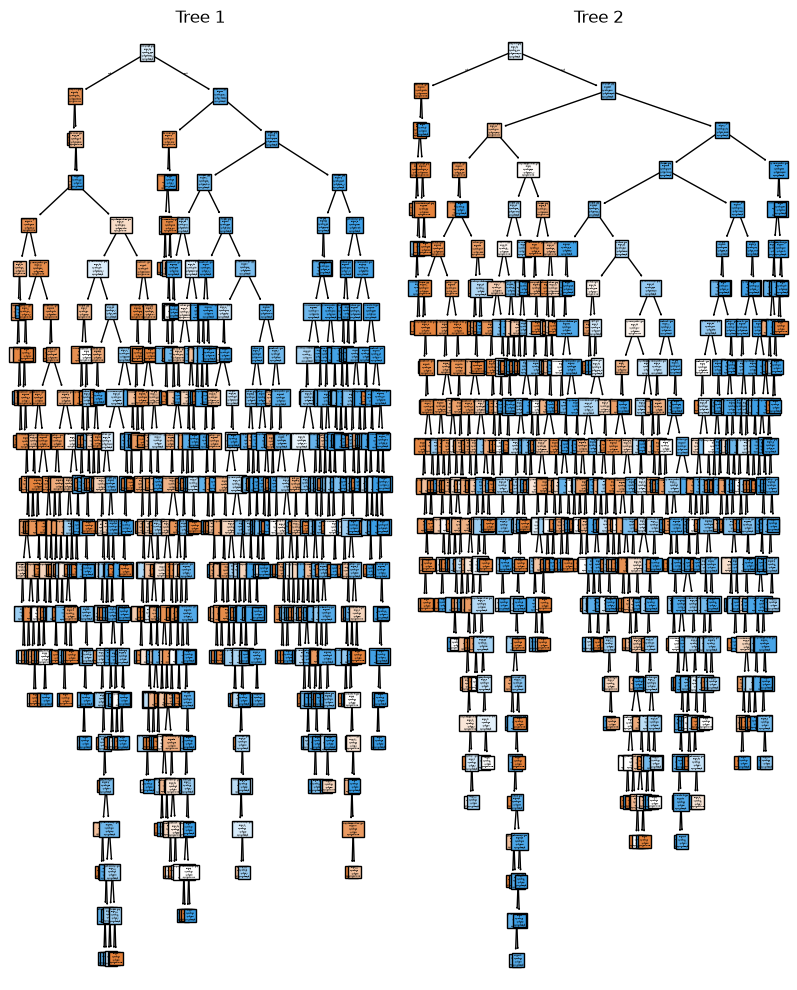

In [15]:
# Peek a few trees
plt.figure(figsize=(20, 10))
for i in range(2):
    plt.subplot(1, 5, i + 1)
    plot_tree(model.estimators_[i], filled=True, feature_names=X.keys(), class_names=['-1 (phishing)', '1 (legitimate)'])
    plt.title(f'Tree {i + 1}')
plt.tight_layout()
plt.show()

## Evaluation (Riikka)


The two different model both got accuracy, precision and recall scores over 85% in predicting both phishing and legitimate websites. The goal set in the beginning was reached. While both models could be used to predict websites legitimacy fairly accurately based on the results on the testing data, the performance of the model could be less accurate on a new real-word data. More testing is required in order be sure that performance of the models is as high as this analysis suggests. <br>

Incorrectly predicting a websites legitimacy can lead to serious risk of personal information loss, so while these models' performance is high one should never blindly trust the predictions. The models may give an idea whether a website is a phishing website or not but they should not be used to make a final decision. <br>

The second model using the Random Forrest algorithm has better performance, as it is able to make more correct predictions, but it is also seems to be slower and require more memory to use. This can make it more costly than the model using the Decision Tree algorithm. The second model is also harder to interpret than the first one reducing the model's transparency.


## Deployment (Riikka)


The models could be used in a web browser application to predict whether a certain website is insecure and dangerous. This could alert users to a possible phishing scams and reduce personal information loss. The models could be deployed as they are to developers to use but further testing on different data is recommended to improve the models' performance and reliability.
